In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data = np.load("/home/max/Nextcloud/Physik/Master/Semester 4/CompPhys/code-data/data/triangular_interpolation_data.npz")

points = data["points"]
phi_data = data["phi_data"]
triangles = data["triangles"]

print(points.shape)
print(phi_data.shape)
print(triangles.shape)

(100, 2)
(100,)
(187, 3)


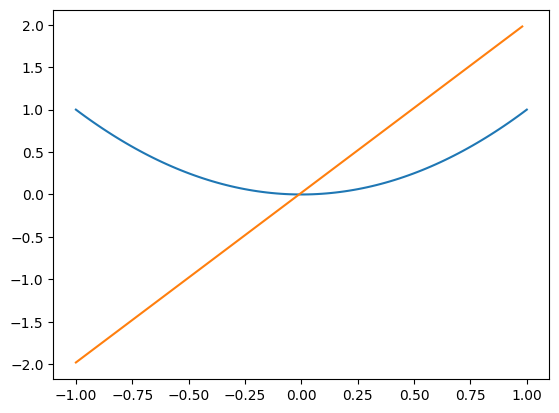

In [ ]:
xlin = np.linspace(-1, 1, 100)

f = xlin**2

h = xlin[1] - xlin[0]

df = (f[1:] - f[:-1]) / h

plt.plot(xlin, f)
plt.plot(xlin[:-1], df)
plt.show()

In [ ]:
print(
    f.shape,
    np.gradient(
        f,
    ).shape,
)

(100,) (100,)


In [25]:
def plot_triangles(points, triangles):
    for triangle in triangles:
        triangle_points = points[triangle]
        plt.plot(
            [triangle_points[0, 0], triangle_points[1, 0], triangle_points[2, 0], triangle_points[0, 0]],
            [triangle_points[0, 1], triangle_points[1, 1], triangle_points[2, 1], triangle_points[0, 1]],
            "k-",
            alpha=0.1,
        )

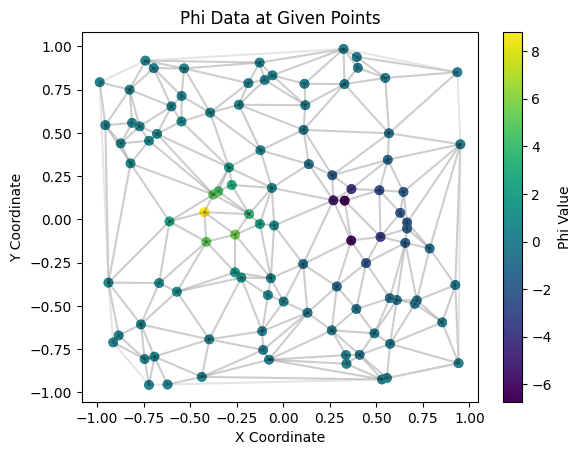

In [26]:
plot_triangles(points, triangles)
plt.scatter(points[:, 0], points[:, 1], c=phi_data, cmap="viridis")
plt.colorbar(label="Phi Value")
plt.title("Phi Data at Given Points")
plt.xlabel("X Coordinate")
plt.scatter(points[:, 0], points[:, 1], c=phi_data, cmap="viridis")

plt.ylabel("Y Coordinate")
plt.show()

In [ ]:
def barycentric_interpolation(points, triangle, phi_data, x, y):
    x1, y1 = points[triangle[0]]
    x2, y2 = points[triangle[1]]
    x3, y3 = points[triangle[2]]

    phi1 = phi_data[triangle[0]]
    phi2 = phi_data[triangle[1]]
    phi3 = phi_data[triangle[2]]

    lambda1 = ((y2 - y3) * (x - x3) + (x3 - x2) * (y - y3)) / ((y2 - y3) * (x1 - x3) + (x3 - x2) * (y1 - y3))
    lambda2 = ((y3 - y1) * (x - x3) + (x1 - x3) * (y - y3)) / ((y2 - y3) * (x1 - x3) + (x3 - x2) * (y1 - y3))
    lambda3 = 1 - lambda1 - lambda2

    if lambda1 < 0 or lambda2 < 0 or lambda3 < 0:
        # print("Point outside of triangle")#
        raise ValueError("Point is outside the triangle")

    phi = lambda1 * phi1 + lambda2 * phi2 + lambda3 * phi3
    return phi

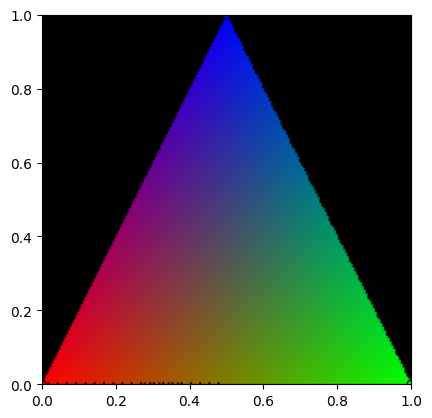

In [ ]:
p1 = np.array([0.0, 0.0])
p2 = np.array([1.0, 0.0])
p3 = np.array([0.5, 1.0])
v1 = np.array([1.0, 0.0, 0.0])
v2 = np.array([0.0, 1.0, 0.0])
v3 = np.array([0.0, 0.0, 1.0])

points = np.array([p1, p2, p3])
triangles = np.array([[0, 1, 2]])
phi_data = np.array([v1, v2, v3])

nx = 200
ny = 200
xlin = np.linspace(points[:, 0].min(), points[:, 0].max(), nx)
ylin = np.linspace(points[:, 1].min(), points[:, 1].max(), ny)
X, Y = np.meshgrid(xlin, ylin)
Z = np.zeros((nx, ny, 3))

for i in range(nx):
    for j in range(ny):
        x, y = X[i, j], Y[i, j]
        for triangle in triangles:
            try:
                Z[i, j] = barycentric_interpolation(points, triangle, phi_data, x, y)
            except:
                continue

plt.imshow(Z, extent=[xlin.min(), xlin.max(), ylin.min(), ylin.max()], origin="lower")
plt.scatter(points[:, 0], points[:, 1], c=phi_data, edgecolor="k")
plot_triangles(points, triangles)

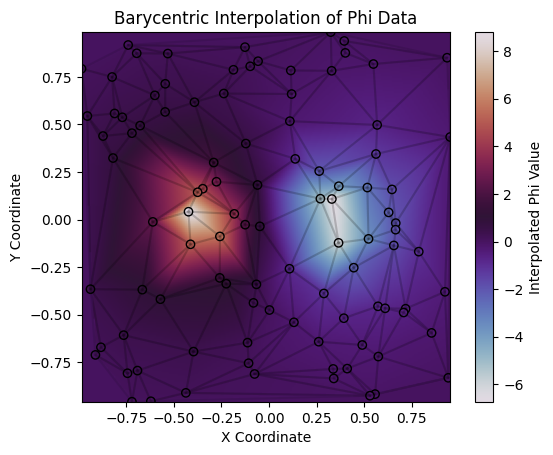

In [27]:
nx = 200
ny = 200
xlin = np.linspace(points[:, 0].min(), points[:, 0].max(), nx)
ylin = np.linspace(points[:, 1].min(), points[:, 1].max(), ny)
X, Y = np.meshgrid(xlin, ylin)
Z = np.zeros_like(X)
for i in range(nx):
    for j in range(ny):
        x, y = X[i, j], Y[i, j]
        for triangle in triangles:
            try:
                Z[i, j] = barycentric_interpolation(points, triangle, phi_data, x, y)
                break
            except ValueError:
                continue

plt.imshow(Z, extent=(xlin.min(), xlin.max(), ylin.min(), ylin.max()), origin="lower", cmap="twilight")
plt.scatter(points[:, 0], points[:, 1], c=phi_data, cmap="twilight", edgecolor="k")
plot_triangles(points, triangles)
plt.colorbar(label="Interpolated Phi Value")

plt.title("Barycentric Interpolation of Phi Data")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

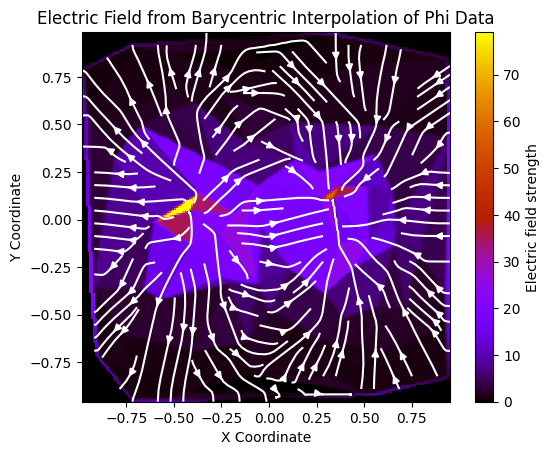

In [30]:
def electric_field(phi, xlin, ylin):
    Ey, Ex = np.gradient(phi, ylin, xlin)
    return -Ex, -Ey


Ex, Ey = electric_field(Z, xlin, ylin)
E_abs = np.sqrt(Ex**2 + Ey**2)
plt.streamplot(X, Y, Ex, Ey, color="w")
plt.imshow(
    E_abs, extent=(xlin.min(), xlin.max(), ylin.min(), ylin.max()), origin="lower", cmap="gnuplot", interpolation="none"
)
plt.colorbar(label="Electric field strength")
plt.title("Electric Field from Barycentric Interpolation of Phi Data")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

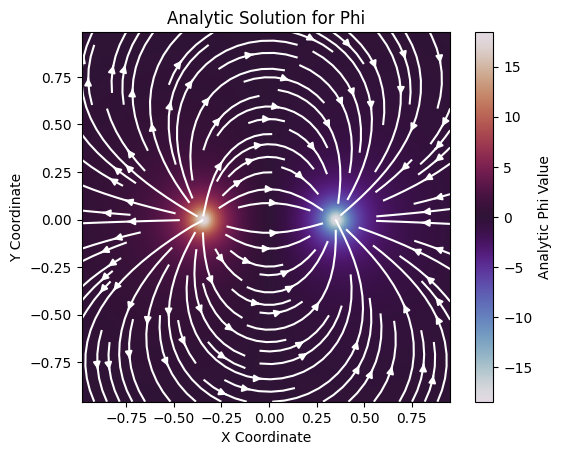

In [31]:
q1, q2 = 1.0, 1.0
x1, y1 = [-0.35, 0.0]
x2, y2 = [0.35, 0.0]
eps = 0.05
E0 = 0.3


def phi_analytic(x, y):
    return (
        q1 / (np.sqrt((x - x1) ** 2 + (y - y1) ** 2 + eps**2))
        - q2 / (np.sqrt((x - x2) ** 2 + (y - y2) ** 2 + eps**2))
        + E0 * x
    )


def electric_field_analytical(x, y):
    Ex = (
        q1 * (x - x1) / (np.sqrt((x - x1) ** 2 + (y - y1) ** 2 + eps**2)) ** 3
        - q2 * (x - x2) / (np.sqrt((x - x2) ** 2 + (y - y2) ** 2 + eps**2)) ** 3
        + E0
    )
    Ey = (
        q1 * (y - y1) / (np.sqrt((x - x1) ** 2 + (y - y1) ** 2 + eps**2)) ** 3
        - q2 * (y - y2) / (np.sqrt((x - x2) ** 2 + (y - y2) ** 2 + eps**2)) ** 3
    )
    return Ex, Ey


Z_analytic = phi_analytic(X, Y)
plt.streamplot(X, Y, *electric_field_analytical(X, Y), color="white")
plt.imshow(Z_analytic, extent=(xlin.min(), xlin.max(), ylin.min(), ylin.max()), origin="lower", cmap="twilight")
plt.colorbar(label="Analytic Phi Value")
plt.title("Analytic Solution for Phi")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

In [19]:
# delaunay triangulation
from scipy.spatial import Delaunay

points = np.random.uniform(-1, 1, (1000, 2))
tri = Delaunay(points)
triangles = tri.simplices
phi_data = phi_analytic(points[:, 0], points[:, 1])
